# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# 1.1 Импортируем библиотеку pandas
import pandas as pd

# 1.2 Загружаем данные
sessions_history_df=pd.read_csv('/datasets/sessions_project_history.csv')

# 1.3 Выведем на экран первые 5 строк
sessions_history_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
# 1 Выводим уникальных пользоваталей и сессиии
user_sessions=sessions_history_df.groupby('user_id')['session_id'].unique()
print(user_sessions)

user_id
00005FB6A13A6FBE                 [0412A88ADCBDFA14, AE8C612624715CDB]
0000B15A18D77ED9    [894EA45DA2B6EFA9, 552441E2C4602D9C, 0F27EDD74...
0000C4E3A4A571A9                 [D69B851273B70727, D38FE0D82B3E1B56]
000293FAF9E67A81    [51005CC42AB3CDC6, 2CB794E2B6A7E273, A64F307CA...
00029C5AE889A6C3                 [397A57D41D5B334B, 3677108EF4572016]
                                          ...                        
FFFCDE7746148710    [61AB969C3574447D, 136B23F15C23B850, 06187492E...
FFFDD413285E753F    [DCAEECF888FCE227, 153775EE559267F2, 4825A722A...
FFFECBA0F2578AB0                 [740618A1188E8D08, B5CC52618BFC769F]
FFFEDB68228B5F21    [29DC0EF6288F826E, F26ADA4F1652DF3D, 788670B2A...
FFFF4228DF580C3B    [A2B3EDE399A3E543, BFEF5D57DA141ABB, EAF5C988A...
Name: session_id, Length: 134039, dtype: object


In [3]:
# 2 Выведем все данные таблицы sessions_history
max_user=sessions_history_df['user_id'].value_counts().index[0]

print(sessions_history_df[sessions_history_df['user_id']==max_user])

                 user_id        session_id session_date     session_start_ts  \
124515  6A73CB5566BB494D  110E3F28C1F5415F   2025-08-28  2025-08-28 18:58:19   
196252  6A73CB5566BB494D  D68C8D98A0F1C439   2025-08-29  2025-08-29 20:53:27   
242428  6A73CB5566BB494D  6587D217472BF807   2025-08-30  2025-08-30 13:08:22   
304287  6A73CB5566BB494D  A9BC25593D056F8E   2025-09-01  2025-09-01 18:52:49   
346611  6A73CB5566BB494D  CB6F9C4191FAF6F6   2025-09-03  2025-09-03 22:49:08   
363510  6A73CB5566BB494D  9C609432F6E6535A   2025-09-04  2025-09-04 13:59:46   
391902  6A73CB5566BB494D  5D892E33B97A257A   2025-09-06  2025-09-06 18:46:55   
404322  6A73CB5566BB494D  22A9BD3861F49087   2025-09-07  2025-09-07 18:33:49   
415489  6A73CB5566BB494D  F70E351154B092DC   2025-09-08  2025-09-08 20:30:22   
425805  6A73CB5566BB494D  84A3DC0CFF449F53   2025-09-09  2025-09-09 16:36:04   

       install_date  session_number  registration_flag  page_counter region  \
124515   2025-08-28               1     

In [4]:
# 3 Изучим таблицу на одного пользователя
one_user = sessions_history_df[sessions_history_df['user_id'] == max_user]

# Проверяем результат:
print(one_user)

                 user_id        session_id session_date     session_start_ts  \
124515  6A73CB5566BB494D  110E3F28C1F5415F   2025-08-28  2025-08-28 18:58:19   
196252  6A73CB5566BB494D  D68C8D98A0F1C439   2025-08-29  2025-08-29 20:53:27   
242428  6A73CB5566BB494D  6587D217472BF807   2025-08-30  2025-08-30 13:08:22   
304287  6A73CB5566BB494D  A9BC25593D056F8E   2025-09-01  2025-09-01 18:52:49   
346611  6A73CB5566BB494D  CB6F9C4191FAF6F6   2025-09-03  2025-09-03 22:49:08   
363510  6A73CB5566BB494D  9C609432F6E6535A   2025-09-04  2025-09-04 13:59:46   
391902  6A73CB5566BB494D  5D892E33B97A257A   2025-09-06  2025-09-06 18:46:55   
404322  6A73CB5566BB494D  22A9BD3861F49087   2025-09-07  2025-09-07 18:33:49   
415489  6A73CB5566BB494D  F70E351154B092DC   2025-09-08  2025-09-08 20:30:22   
425805  6A73CB5566BB494D  84A3DC0CFF449F53   2025-09-09  2025-09-09 16:36:04   

       install_date  session_number  registration_flag  page_counter region  \
124515   2025-08-28               1     

Пользователь `10E0DEFC1ABDBBE0` установил приложение 14 августа 2025 года. 

Совершил 10 сессий за 11 дней,но так и не зарегистрировался. 

Использует телефон на операционной системе `Android` в регионе `CIS`.

Просматривает 1-4 страниц за сессию.

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [5]:
# 1 Рассчитаем число уникальных пользоваталей и число для зарегестрированных пользователей для каждого дня
unique_users = sessions_history_df.groupby('session_date').agg(
    # Всего пользователей
    total_users =('user_id','nunique'),
    # Всего зарегиестированных пользоваталей
    registrations_users=('registration_flag','sum')
).reset_index()


# Проверяем
print(unique_users)

   session_date  total_users  registrations_users
0    2025-08-11         3919                  169
1    2025-08-12         6056                  336
2    2025-08-13         8489                  464
3    2025-08-14        10321                  625
4    2025-08-15        14065                  840
5    2025-08-16        12205                  916
6    2025-08-17        11200                  833
7    2025-08-18        10839                  860
8    2025-08-19        12118                  831
9    2025-08-20        13514                 1008
10   2025-08-21        15051                 1063
11   2025-08-22        17563                 1251
12   2025-08-23        16082                 1253
13   2025-08-24        13683                 1181
14   2025-08-25        13635                 1060
15   2025-08-26        13289                 1050
16   2025-08-27        14766                 1076
17   2025-08-28        15388                 1175
18   2025-08-29        16873                 1174


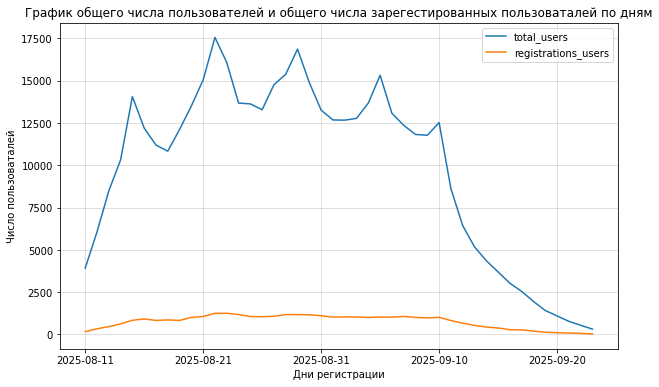

In [6]:
# 2 Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням

# Импортируем библиотеку matplotlib:

import matplotlib.pyplot as plt

# Строим график
unique_users.plot.line(
x='session_date',
y=['total_users','registrations_users'],
title= 'График общего числа пользователей и общего числа зарегестированных пользоваталей по дням',
xlabel = 'Дни регистрации',
ylabel= 'Число пользоваталей',
figsize=(10,6)
 
    
)
plt.legend()
plt.grid(True,alpha=0.5)
plt.show()

На графике заметен рост пользоваталей с `4000` до пикового значения `17 500`(22 августа), затем виден спад до ~1000 к концу сентября.

В конце сентября аудитория сократилась в ~6 раз, приложение теряет аудиторию,возможно это связано с окончанием промо-акции/рекламной компании.

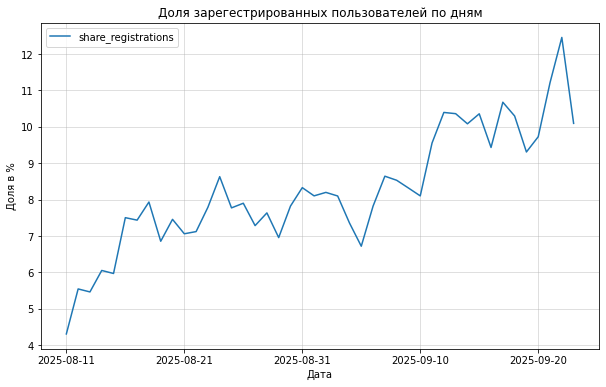

In [7]:
# 3 Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

# Находим долю: 
unique_users['share_registrations']=unique_users['registrations_users']/unique_users['total_users']*100

# Строим график:
unique_users.plot.line(
x= 'session_date',
y= 'share_registrations',
title = 'Доля зарегестрированных пользователей по дням' ,
xlabel= 'Дата',
ylabel = 'Доля в %',
figsize=(10,6)
)

plt.legend()
plt.grid(True,alpha=0.5)
plt.show()


Приложение теряет аудиторию,но доля регистраций растет. 

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

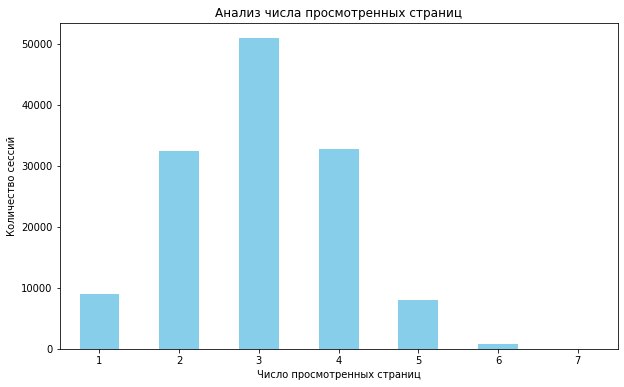

In [8]:
# 1 Найдем первую сессиб пользоватателей

first_sessions = sessions_history_df[sessions_history_df['session_number']==1]

# 2 Находим колличества первых сессий для значения кажого колличества просмотренных страниц 

viewed_pages=first_sessions['page_counter'].value_counts().sort_index()


# 3 Строим диаграмму:

viewed_pages.plot(
kind='bar',
title='Анализ числа просмотренных страниц',
legend=False,
ylabel='Количество сессий',
xlabel='Число просмотренных страниц',
rot=0,
color='skyblue',
figsize=(10,6)

)
plt.show()






Большинство пользоваталей просматривает 3 и 4 страницы. 

Пик активности приходится на 3 странице(`50 000` сессий )

Резкий спад происходит после просмотра 4 страницы

Многие пользователи изучают приложение, а не уходят сразу. Это говорит нам о том,что приложение интересное,пользователи просматривают несколько страниц в первую сессию.



#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

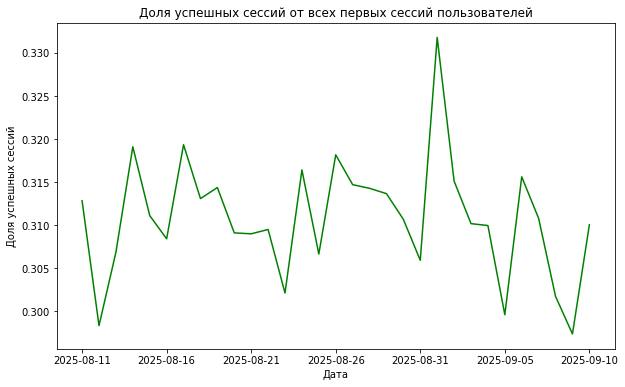

In [9]:
# 1 Создаем доп столбец
sessions_history_df['good_session'] = 0

sessions_history_df.loc[sessions_history_df['page_counter'] >=4, 'good_session'] = 1

# 2 Оставим только первые сессии:
first = sessions_history_df[sessions_history_df['session_number']==1]

# 3 Находим долю успешных сессий первых пользователей:
fraction_first=first.groupby('session_date')['good_session'].mean().reset_index()

# 4 Строим график: 
fraction_first.plot(
kind='line',
title='Доля успешных сессий от всех первых сессий пользователей',
legend=False,
y='good_session',
x='session_date',
rot=0,
color='green',
figsize=(10,6)

)
plt.ylabel('Доля успешных сессий')
plt.xlabel('Дата')
plt.show()



Доля успешных сессий колеблется в диапозоне от 29-33%

Пиковое значение приходится на ~ 2 сентября (33%)

Каждая третья первая сессия - успешная.

Качество первых сессий улучшается со временем, пользователям  приложение интересно. 




### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект

p1=p
p2 =  p * ( 1 + mde) 

effect_size = proportion_effectsize(p1, p2)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size =effect_size ,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


<div class="alert alert-info"> <b>Комментарий студента:</b> 
    
Для каждой группы эксперимента нужно `41 040` пользователь

Всего для эксперимента нужно 41 040 * 2 =  `82 080`</div>

#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [11]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = unique_users['total_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
users_need = sample_size * 2
test_duration=ceil(users_need / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


<div class="alert alert-info"> <b>Комментарий студента:</b> 
    
    Средний дневной трафик `9907` пользоваталей в день

    Длительность теста : `9` дней </div> 

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Процентная разница между группами: 0.74%
Количество пользователей в группе А: 1477
Количество пользователей в группе В: 1466


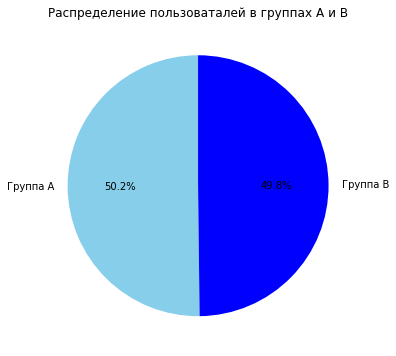

In [12]:
# 1 Сохраним в датафрейм sessions_test_part файл с историческими данными:
sessions_test_part_df=pd.read_csv('/datasets/sessions_project_test_part.csv')

# 2 Рассчитаем количество уникальных пользовательей в каждой из экспериментальных групп для 1 дня наблюдения
one_date = sessions_test_part_df['session_date'].iloc[0] 

one_day = sessions_test_part_df[sessions_test_part_df['session_date'] == one_date]

experimental_group = one_day.groupby('test_group')['user_id'].nunique() 

# 3 Рассчитаем и выведем на экран процентнную разницу в кол-ве пользователей в группах А и Б: 

# Импортируем библиотеку для будущей визуазилазии(круговая диаграмма)
import matplotlib.pyplot as plt 

# Пдставляем в формулу соответствующие значения:
a = experimental_group['A']
b = experimental_group['B']

p = 100 * abs(a - b) / a

# 4 Выводим резльтаты расчета по формуле:
print(f"Процентная разница между группами: {p:.2f}%")
print(f"Количество пользователей в группе А: {a}")
print(f"Количество пользователей в группе В: {b}")

# 5 Строим круговую диаграмму: 

plt.figure(figsize=(10,6))
plt.pie([a,b],
       labels=['Группа А','Группа В'],
        autopct='%1.1f%%',
        colors=['skyblue','blue'],
        startangle = 90)

plt.title('Распределение пользоваталей в группах A и B')
plt.show()




<div class="alert alert-info"> <b>Комментарий студента:</b> 

Разница между группами А и В составляет `0.74%`, группы сбалансированы. 

Это говорит нам о хорошем распределении пользователей. </div>

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [13]:
# Посчитаем пересечение в группах А и Б:
users_group_a = set(sessions_test_part_df[sessions_test_part_df['test_group'] == 'A']['user_id'])
users_group_b = set(sessions_test_part_df[sessions_test_part_df['test_group'] == 'B']['user_id'])

# Находим пользоватателей в обеих группах: 
intersection_a_and_b = users_group_a & users_group_b
                     
# Проверяем: 
print(f"Количество пользователей в группе А : {len(users_group_a )}")
print(f"Количество пользователей в группе B : {len(users_group_b )}")
print(f"Пользователи в обеих группах : {len(intersection_a_and_b)}")
                     

Количество пользователей в группе А : 1477
Количество пользователей в группе B : 1466
Пользователи в обеих группах : 0


Мы убедились в том, что группы независимы.

Никто из пользоваталей не оказалася в обеих группах одновременно.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


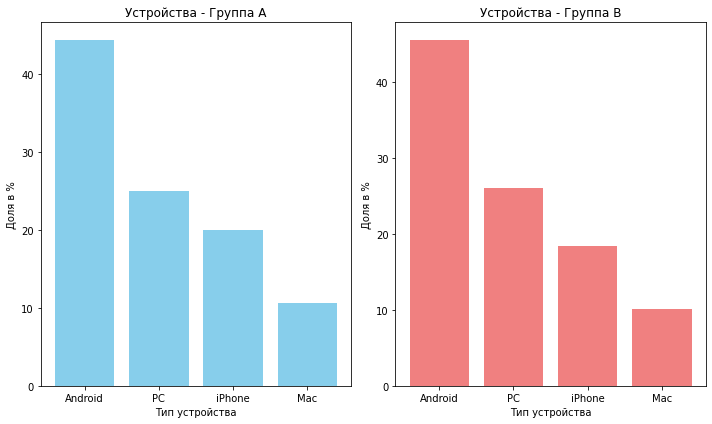

----------------------------------------
Android: 44.4%
PC: 25.0%
iPhone: 20.0%
Mac: 10.6%
----------------------------------------
Android: 45.6%
PC: 26.0%
iPhone: 18.3%
Mac: 10.1%


In [14]:
# 1 Найдем распределение по устройствам:
devices_a = one_day[one_day['test_group'] =='A'].groupby('user_id')['device'].first().value_counts(normalize=True)*100
devices_b = one_day[one_day['test_group'] =='B'].groupby('user_id')['device'].first().value_counts(normalize=True)*100

# 2  Строим столбчатые диаграммы
fig,axes=plt.subplots(1,2, figsize=(10,6))
# Устройства группы А и В

axes[0].bar(devices_a.index,devices_a.values,color='skyblue')
axes[0].set_title('Устройства - Группа A')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля в %')

axes[1].bar(devices_b.index,devices_b.values,color='lightcoral')
axes[1].set_title('Устройства - Группа B')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Доля в %')

plt.tight_layout()
plt.show()

# Проверяем долю каждого устройста: 

# Группа А:
print("-"*40)
for device in devices_a.index:
    print(f"{device}: {devices_a[device]:.1f}%") 

# Группа В:
print("-"*40)
for device in devices_b.index:
    print(f"{device}: {devices_b[device]:.1f}%") 

<div class="alert alert-info"> <b>Комментарий студента:</b> Распределение по типам устройств в группах А и В практически идентично.

Небольшие расхождения находится в пределах допустимой погрешности. </div>




#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

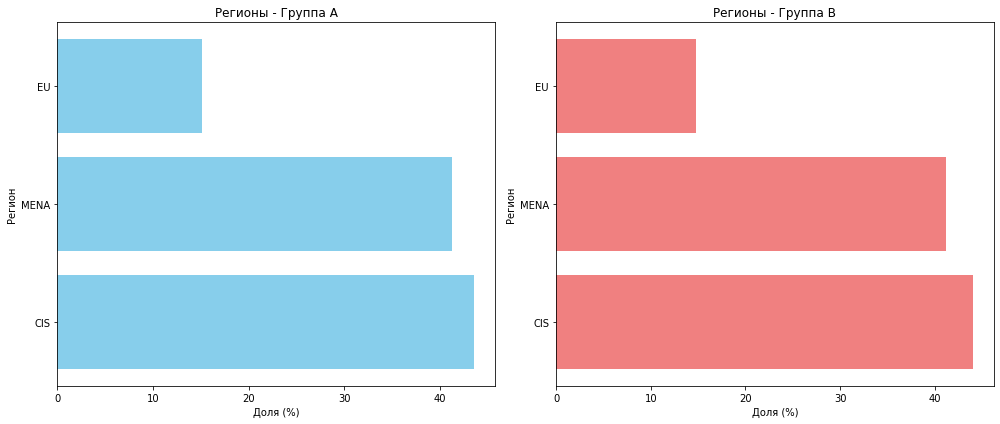

----------------------------------------
Группа А:
CIS: 43.6%
MENA: 41.2%
EU: 15.2%
----------------------------------------
Группа В:
CIS: 44.0%
MENA: 41.2%
EU: 14.8%


In [15]:
# 1 Диаграмма доля каждого региона для пользователей из группы A

# 2 Найдем распределение по регионам:
regions_a = one_day[one_day['test_group'] =='A'].groupby('user_id')['region'].first().value_counts(normalize=True)*100
regions_b = one_day[one_day['test_group'] =='B'].groupby('user_id')['region'].first().value_counts(normalize=True)*100

# 3  Строим столбчатые диаграммы
fig,axes=plt.subplots(1,2, figsize=(14,6))

# Регионы группы А и В

# Регионы группы А
axes[0].barh(regions_a.index, regions_a.values, color='skyblue')
axes[0].set_title('Регионы - Группа A')
axes[0].set_xlabel('Доля (%)')
axes[0].set_ylabel('Регион')

# Регионы группы Б
axes[1].barh(regions_b.index, regions_b.values, color='lightcoral')
axes[1].set_title('Регионы - Группа B')
axes[1].set_xlabel('Доля (%)')
axes[1].set_ylabel('Регион')

plt.tight_layout()
plt.show()

# Проверяем долю каждого устройства:
# Группа А:
print("-"*40)
print("Группа А:")
for region in regions_a.index:
    print(f"{region}: {regions_a[region]:.1f}%") 

# Группа В:
print("-"*40)
print("Группа В:")
for region in regions_b.index:
    print(f"{region}: {regions_b[region]:.1f}%") 

<div class="alert alert-info"> <b>Комментарий студента:</b> 

Пользователи распределены по регионам в группах А и В практически равномерно.

Небольшие расхождения:
    
    CIS в группе A: 43.6%
    CIS в группе В: 44.0%

    EU в группе А: 15.2%
    EU в группе В: 14.8%
        
Небольшие расхождения находятся в допустимой погрешности. </div> 

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

<div class="alert alert-info"> <b>Комментарий студента:
    
    
    
Обнаружено различие в количестве пользователей в двух группах - `0.74%`

Выборки являются независмимыми, поскольку каждый пользователь был случайным образом отнесен только одной из групп(А или В). Пересечение пользователей из тестовой и контрольной групп не обнаружено. 
    
Пользователи распределены между группами `A` и  `B` равномерно, как по количеству, так и по категориальным переменным. Небольшие расхождения находятся в пределах допустимой погрешности.
    
  
    
    
    
    
    
    
    
 </b> Например, вот так.</div>

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [16]:
# 1 Сохраняем новый датафрейм sessions_test
sessions_test_df=pd.read_csv('/datasets/sessions_project_test.csv')

# 2 Создаем новый столбец good_session
sessions_test_df['good_session'] = 0 

sessions_test_df.loc[sessions_test_df ['page_counter'] >=4, 'good_session'] =1 

print(sessions_test_df.head())


            user_id        session_id session_date     session_start_ts  \
0  6DAE3B3654DA738E  C69249E26E58F6E2   2025-10-26  2025-10-26 18:15:05   
1  0A3FE5D1DD59110A  66D66D7C9F5181B7   2025-10-21  2025-10-21 17:04:53   
2  2041F1D7AA740B88  50DE51D42215E74C   2025-10-23  2025-10-23 17:39:29   
3  43D7585009168086  5763C0C353C22263   2025-10-24  2025-10-24 15:01:57   
4  15AD68B14D62D88C  B1AD09F93C1053BC   2025-10-17  2025-10-17 17:34:39   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-10-16               3                  0             3   MENA   
1   2025-10-15               2                  1             2    CIS   
2   2025-10-19               3                  0             2   MENA   
3   2025-10-18               4                  0             1    CIS   
4   2025-10-17               1                  0             2   MENA   

    device test_group  good_session  
0  Android          A             0  
1  Android          B       

В начале тестового периода пользователи просматривают меньше страниц.

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

<div class="alert alert-info"> <b>Комментарий студента:</b> 
    
    
`Нулевая гинотеза(H0)` - новый алгорим рекомендаций не влияет на долю успешных первых сессий.

`Альтернативная гипотеза(H1)` - новый алгоритм рекомендаций увеличивает долю успешных первых сессий. 

`Метрика` - доля успешных первых сессий, с просмотренными 4 и более страниц.
    

`Прокси-метрики` :
   
     - Количество просмотренных страниц во время первой сессии;
    - Время первой сессии;
    - Взаиомдействие с видео(Лайк/Сохранение);                                                                                      

`Барьерные метрики` :  

    - Стабильность приложения(частота сбоев);
    - Скорость загрузки рекомандаций ;
    - Доля пользователей покинувших приложение без действия ;   
</div>




#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [17]:
# 1 Рассчитаем долю успешных первых сессий для выборок A и B

# Выбираем одну сессию 
first=sessions_test_df[sessions_test_df['session_number']== 1 ]

good_a=first[first['test_group']=='A']['good_session'].mean()
good_b=first[first['test_group']=='B']['good_session'].mean()

# Находим разницу
diff = good_a-good_b

# 2 Выведем резултат и найдем разницу в показателе:
print(f"Группа A: {good_a:.2%}")
print(f"Группа B: {good_b:.2%}")
print(f"Разница между А и В : {diff:+.2%}")

Группа A: 31.57%
Группа B: 31.47%
Разница между А и В : +0.11%


Разница между выборками А и В минимальна(0.11%),новый алгоритм не повлиял на показатель успешных сесиий.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [18]:
from statsmodels.stats.proportion import proportions_ztest

# Берем первые сессии
first = sessions_test_df[sessions_test_df['session_number']==1]

# Группа А:
a_z_test=first[first['test_group']=='A']['good_session'].sum()
a_len=len(first[first['test_group']=='A'])

# Группа B:
b_z_test=first[first['test_group']=='B']['good_session'].sum()
b_len=len(first[first['test_group']=='B'])

alpha = 0.05

# Статистический тест:

stat_ztest,p_value_ztest=proportions_ztest(
    [a_z_test,b_z_test],
    [a_len,b_len],
    alternative='smaller'
)

print(p_value_ztest)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'p_value={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')


0.5783523649187868
pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение!


Нулевая гипотеза находит подтверждение. Разница между группами статистически незначима.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Результаты A/B-эксперимента:

    1) Участники: Пользователи в группе А: `1477` ,в группе В: `1466` ;
    
    2) Длительность эксперимента: `1 день` ;
    
    3) Внедрение нового алгоритма рекомендаций не повлияло,результат не принес существенные изменения
    
    4) pvalue=0.5783523649187868 > 0.05. Разница статистически незначима.
    
    5) Нововведение внедрять не стоит, новый алгоритм рекомендаций не принес существенных измененений. 
    
    
    
    